# bdap-entrate-stato v0

Sanity check minimo sul mart `anno x titolo x natura` costruito dal candidate.

In [5]:
from pathlib import Path

import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False

SLUG = "bdap_entrate_stato"
MART_TABLE = "mart_entrate_titolo_natura_anno"
ANNO_RUN = 2024
ANNI_FOCUS = [2008, 2020, 2024]

start_dir = Path.cwd().resolve()
candidate_dir = None
for probe in [start_dir, *start_dir.parents]:
    if (probe / "dataset.yml").exists():
        candidate_dir = probe
        break

if candidate_dir is None:
    raise FileNotFoundError(
        f"dataset.yml non trovato risalendo da {start_dir}. Apri il notebook dalla cartella candidate o notebooks/."
    )

mart_path = (candidate_dir / ".." / ".." / "out" / "data" / "mart" / SLUG / str(ANNO_RUN) / f"{MART_TABLE}.parquet").resolve()
if not mart_path.exists():
    raise FileNotFoundError(f"Mart non trovato: {mart_path}")

df = pd.read_parquet(mart_path)
df.head()

,anno,codice_titolo,titolo,titolo_breve,codice_natura,natura,totale_cp,totale_cs,quota_cp,quota_cs
0,2008,1,TITOLO I - ENTRATE TRIBUTARIE,ENTRATE TRIBUTARIE,1,Entrate ricorrenti,4.514661e+11,4.321901e+11,0.616459,0.573338
1,2008,1,TITOLO I - ENTRATE TRIBUTARIE,ENTRATE TRIBUTARIE,2,Entrate non ricorrenti,2.115000e+09,2.115000e+09,0.002888,0.002806
2,2008,2,TITOLO II - ENTRATE EXTRA-TRIBUTARIE,ENTRATE EXTRA-TRIBUTARIE,1,Entrate ricorrenti,3.168345e+10,2.471669e+10,0.043262,0.032789
3,2008,2,TITOLO II - ENTRATE EXTRA-TRIBUTARIE,ENTRATE EXTRA-TRIBUTARIE,2,Entrate non ricorrenti,8.881980e+08,8.881980e+08,0.001213,0.001178
4,2008,3,TITOLO III - ALIENAZIONE ED AMMORTAMENTO DI BE...,ALIENAZIONE ED AMMORTAMENTO DI BENI PATRIMONIA...,2,Entrate non ricorrenti,3.477914e+09,3.477914e+09,0.004749,0.004614


In [2]:
focus = df[df["anno"].isin(ANNI_FOCUS)].copy()
focus_titolo = (
    focus.groupby(["anno", "codice_titolo", "titolo_breve"], as_index=False)
    [["totale_cp", "quota_cp"]]
    .sum()
)
focus_titolo.sort_values(["anno", "codice_titolo"]).reset_index(drop=True)

,anno,codice_titolo,titolo_breve,totale_cp,quota_cp
0,2008,1,ENTRATE TRIBUTARIE,4.535811e+11,0.619346
1,2008,2,ENTRATE EXTRA-TRIBUTARIE,3.257165e+10,0.044475
2,2008,3,ALIENAZIONE ED AMMORTAMENTO DI BENI PATRIMONIA...,3.477914e+09,0.004749
3,2008,4,ACCENSIONE DI PRESTITI,2.427237e+11,0.331429
4,2020,1,ENTRATE TRIBUTARIE,4.629249e+11,0.433791
5,2020,2,ENTRATE EXTRA-TRIBUTARIE,7.022414e+10,0.065805
6,2020,3,ALIENAZIONE ED AMMORTAMENTO DI BENI PATRIMONIA...,4.183776e+09,0.003920
7,2020,4,ACCENSIONE DI PRESTITI,5.298275e+11,0.496484
8,2024,1,ENTRATE TRIBUTARIE,6.202282e+11,0.492617
9,2024,2,ENTRATE EXTRA-TRIBUTARIE,1.046396e+11,0.083110


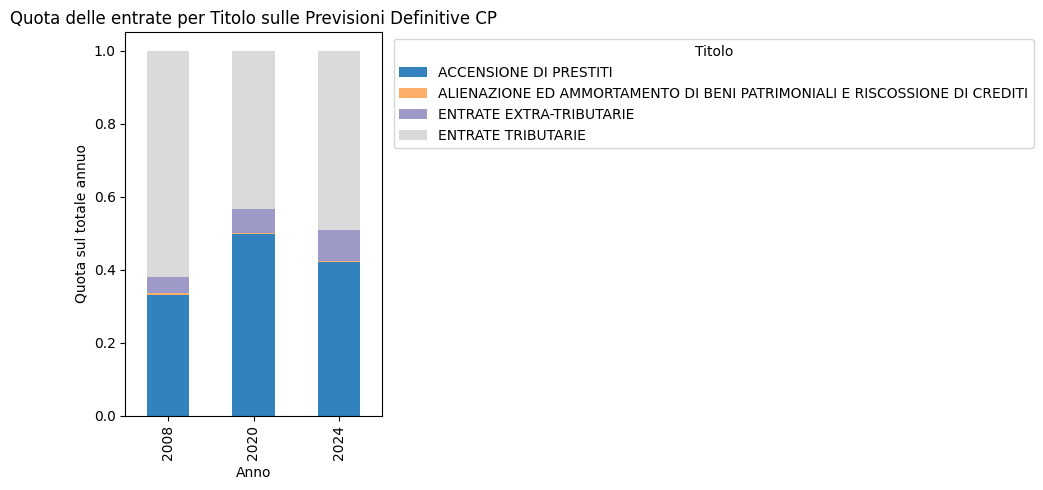

In [3]:
pivot = focus_titolo.pivot(index="anno", columns="titolo_breve", values="quota_cp").sort_index()
if HAS_MATPLOTLIB:
    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab20c")
    ax.set_title("Quota delle entrate per Titolo sulle Previsioni Definitive CP")
    ax.set_xlabel("Anno")
    ax.set_ylabel("Quota sul totale annuo")
    ax.legend(title="Titolo", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib non disponibile nel kernel: mostro solo la tabella pivot")
    display(pivot)

In [4]:
focus_natura = focus[focus["codice_titolo"].isin(["1", "4"])].copy()
focus_natura = focus_natura.sort_values(["anno", "codice_titolo", "codice_natura"])
focus_natura[["anno", "titolo_breve", "natura", "totale_cp", "quota_cp"]].reset_index(drop=True)

,anno,titolo_breve,natura,totale_cp,quota_cp
0,2008,ENTRATE TRIBUTARIE,Entrate ricorrenti,4.514661e+11,0.616459
1,2008,ENTRATE TRIBUTARIE,Entrate non ricorrenti,2.115000e+09,0.002888
2,2008,ACCENSIONE DI PRESTITI,Entrate ricorrenti,2.427237e+11,0.331429
3,2020,ENTRATE TRIBUTARIE,Entrate ricorrenti,4.594092e+11,0.430497
4,2020,ENTRATE TRIBUTARIE,Entrate non ricorrenti,3.515717e+09,0.003294
5,2020,ACCENSIONE DI PRESTITI,Entrate ricorrenti,5.298275e+11,0.496484
6,2024,ENTRATE TRIBUTARIE,Entrate ricorrenti,6.166111e+11,0.489744
7,2024,ENTRATE TRIBUTARIE,Entrate non ricorrenti,3.617149e+09,0.002873
8,2024,ACCENSIONE DI PRESTITI,Entrate ricorrenti,5.311784e+11,0.421889
